208PbのSα

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# CSVファイルを読み込む（nrowsで読み込む行数を指定できるのでメモリに優しい）
df = pd.read_csv('Pb_labeled.csv')


GRtiming = df['GRQ2timing']
LASX = df['LASX']
LAStiming = df['LASQ1timing']
TOT = df['LASTOT']

In [48]:
xdp=df['GRX']
adp=df['GRA']
ydp=df['GRY']
bdp=df['GRB']
GRQ2=df['GRQ2charge']

tracking_gated=df[
    (xdp!=-9999) & (ydp!=-9999)
]

xdp_track=tracking_gated['GRX']
adp_track=tracking_gated['GRA']
ydp_track=tracking_gated['GRY']
bdp_track=tracking_gated['GRB']
GRQ2_track=tracking_gated['GRQ2charge']

# proton_gated=tracking_gated[
#     (GRQ2_track>213.276-21.194*5) & (GRQ2_track<213.276+21.194*5)
# ]

# xdp_proton=proton_gated['GRX']
# adp_proton=proton_gated['GRA']
# ydp_proton=proton_gated['GRY']
# bdp_proton=proton_gated['GRB']
# GRQ2_proton=proton_gated['GRQ2charge']

#合わせる時は、GRQ2_trackとTOTを抽出してから

# ------------------------一旦TOTcの範囲を190-250にしているがわからない
gated_208Pb = df[
    (GRQ2_track>213.276-21.194*5) & (GRQ2_track<213.276+21.194*5) & (TOT+0.0430496*LASX-1.3842e-5*(LASX**2)>190) & (TOT+0.0430496*LASX-1.3842e-5*(LASX**2)<250)
]
gated_208Pb_GRQ2timing = gated_208Pb['GRQ2timing']
gated_208Pb_LASQ1itming = gated_208Pb['LASQ1timing']

# mean = 84.98
# sigma = 17.718

mean = 86.955
sigma = 3.395

#true coincidenceのみ抽出
TDiff = gated_208Pb_LASQ1itming - gated_208Pb_GRQ2timing
true_208Pb = gated_208Pb[
    (TDiff >= mean - 10 * sigma) & (TDiff <= mean + 10 * sigma)
]


true_208Pb_GRQ2timing = true_208Pb['GRQ2timing']
true_208Pb_LASQ1itming = true_208Pb['LASQ1timing']

Text(0, 0.5, 'counts')

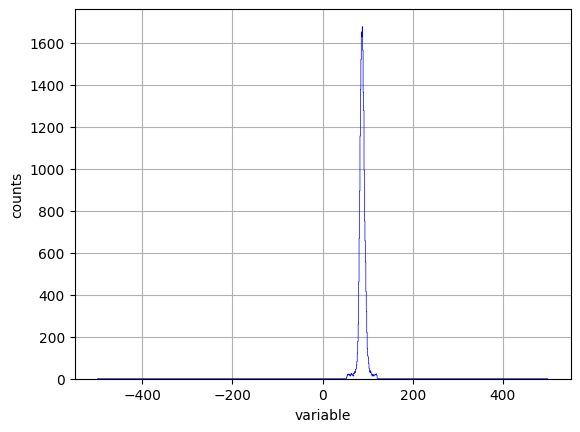

In [49]:
#TDiffのスペクトル
# TDiff = gated_208Pb['LASQ1timing'] - gated_208Pb['GRQ2timing']
TDiff = true_208Pb_LASQ1itming - true_208Pb_GRQ2timing

#input
####################################################
#variables
variable=TDiff
#hist range
range_min=-500
range_max=500
#bin width
x_bin_width = 1
####################################################

fig=plt.figure()
ax=fig.add_subplot(111)

bin_width = x_bin_width # ビン幅を10に設定
bins = np.arange(range_min, range_max + bin_width, bin_width)  # ビンの境界を生成
bin_counts, bin_edges = np.histogram(variable, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # ビンの中心

ax.hist(variable, bins=bins,histtype='step', color='blue', linewidth=0.5)
ax.grid()
ax.set_xlabel('variable')
ax.set_ylabel('counts')

In [55]:
#　コインシデンスとったやつのみ抽出
GRX_true = true_208Pb['GRX']
LASX_true = true_208Pb['LASX']
LASA_true = true_208Pb['LASA']

Tp = (((GRX_true * -0.0000454772 + 0.0027089081 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27
T_alpha = 0.02746 * LASX_true + 63.804

A = -2.57
B = 1274.57

alpha = 0.02746
beta = 63.804

# LASX_true_f = LASA_true * (A * (alpha * GRX_true + beta) + B) + LASX_true
LASX_true_f = LASA_true * (A * Tp + B) + LASX_true

T_alpha_f = 0.02746 * LASX_true_f + 63.804

In [51]:
# # GRX_gated = gated_208Pb['GRX']
# # LASX_gated = gated_208Pb['LASX']

# GRX_gated = true_208Pb['GRX']
# LASX_gated = true_208Pb['LASX']

# Tp = []
# for n in GRX_gated:
#     Tp.append((((n * -0.0000454772 + 0.0027089081 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27)

# T_alpha = []
# for n in LASX_gated:
#     T_alpha.append(0.0269433333 * n + 71.8116666667 - 7.89)

In [56]:
len(true_208Pb)

21214

Text(0, 0.5, 'counts')

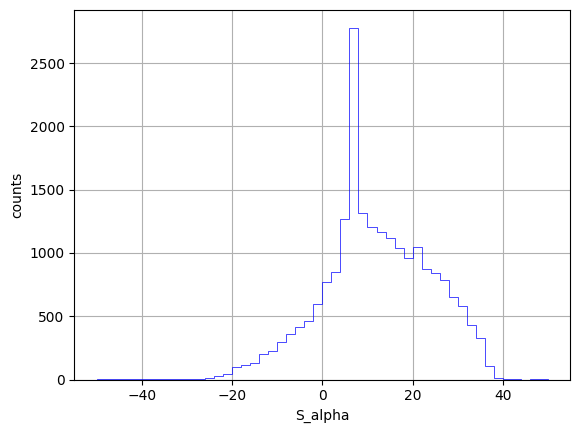

In [57]:
# リスト内包表記で各要素を足し算
S_alpha = [392 - (a + b) for a, b in zip(Tp, T_alpha_f)]

variables = S_alpha

#hist range
range_min=-50
range_max=50
#bin width
x_bin_width=2

####################################################

fig=plt.figure()
ax=fig.add_subplot(111)

bin_width = x_bin_width # ビン幅をx_bin_widthに設定
bins = np.arange(range_min, range_max + bin_width, bin_width)  # ビンの境界を生成
bin_counts, bin_edges = np.histogram(variables, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # ビンの中心

ax.hist(variables, bins=bins,histtype='step', color='blue', linewidth=0.5)
ax.grid()
ax.set_xlabel('S_alpha')
ax.set_ylabel('counts')

Fitting parameters and their uncertainties:
Amp: 812.392 ± 107.616
Mean: 8.970 ± 1.278
Sigma: 7.510 ± 1.821


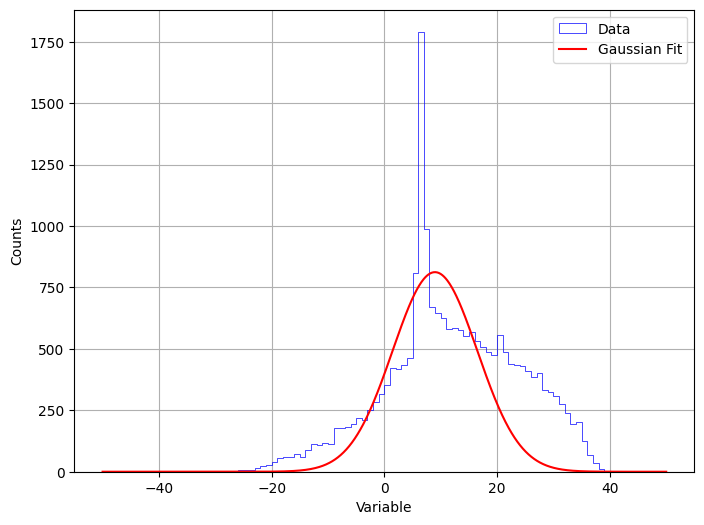

In [58]:
# Fitting
# Input
##############################################################
# Fitする変数
# variable = np.random.normal(loc=0, scale=10, size=1000)  # ダミーデータ
variable = S_alpha
# Histogram range
hist_range_min = -50
hist_range_max = 50
# Bin width
bin_width = 1
# Fit range
fit_range_min = 0
fit_range_max = 20
# Initial parameters for the Gaussian
Amp = 5000
mean = 10
sigma = 5
# Fit parameter boundaries
bound_min = [0, fit_range_min, 0]
bound_max = [np.inf, fit_range_max, np.inf]
##############################################################
# ガウシアン関数の定義
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-0.5 * ((x - mean) / sigma) ** 2)

# データ範囲の選択
bins = np.arange(hist_range_min, hist_range_max + bin_width, bin_width)
bin_counts, bin_edges = np.histogram(variable, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# フィット範囲を選択
mask = (bin_centers >= fit_range_min) & (bin_centers <= fit_range_max)
x_fit = bin_centers[mask]
y_fit = bin_counts[mask]

# 初期パラメータ
initial_guess = [Amp, mean, sigma]

# フィッティングを実行
popt, pcov = curve_fit(gaussian, x_fit, y_fit, p0=initial_guess, bounds=(bound_min, bound_max))

# フィット結果を取得
fit_y = gaussian(x_fit, *popt)

# 全てのフィッティングパラメータとその誤差を出力
print("Fitting parameters and their uncertainties:")
param_names = ["Amp", "Mean", "Sigma"]
for i, param in enumerate(popt):
    error = np.sqrt(pcov[i, i])
    print(f"{param_names[i]}: {param:.3f} ± {error:.3f}")

# フィット結果を描画
x_plot = np.linspace(hist_range_min, hist_range_max, 1000)
y_plot = gaussian(x_plot, *popt)

fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(variable, bins=bins, histtype='step', color='blue', linewidth=0.5, label='Data')
ax.plot(x_plot, y_plot, color='red', linewidth=1.5, label='Gaussian Fit')
ax.grid()
ax.set_xlabel('Variable')
ax.set_ylabel('Counts')
ax.legend()